# **A/B тест двух кампаний для одного продукта**

В процессе A/B-тестирования пользователям случайным образом показываются две разные версии рекламы для одного и того же продукта. Участники контрольной группы взаимодействуют с исходной (базовой) версией, тогда как участники тестовой группы — с изменённой версией продукта.

Цель тестирования — определить, влияет ли новая версия на поведение пользователей, например, увеличивает ли она количество кликов или просмотров по сравнению с оригиналом.

**ГИПОТЕЗА H₀:** Изменение свойств рекламы не влияет на поведение пользователей.

**УСЛОВИЕ:**

**В течение месяца проведено две кампании (два датасета):**

```
control        : Контрольная кампания  (30 человек)
test           : Тестовая кампания     (30 человек)
```

 В тесте изменились свойства рекламы.

**Метрики и результат исследования**
```
Метрика                         Интерпритация                                    Результат

Основные:
- CTR (Click-through rate)      Доля кликов от общего числа показов              🟢 Выросла в 2 раза

Прокси метрики:
- Website Clicks                Количество переходов на сайт (клики по рекламе)  ⚪ Не изменилось
- Impressions                   Общее количество показов рекламы                 🟢 Уменьшилось на 33%
- Add to Cart Rate              Конверсия из просмотра в корзину                 🔴 Уменьшилась на 34%
- CPC                           Стоимость одного клика                           ⚪ Не изменилась
- CPATC (Cost Per Add to Cart)  Стоимость одного добавления в корзину            🔴 Увеличилось на 90%
```

**КРАТКИЕ ВЫВОДЫ**

Качество рекламного креатива улучшилось.

Эффективность рекламы повысилась без увеличения затрат.

Однако, просмотр контента и добавление в корзину снизились и стали меньше, чем в контрольной группе.

Тестовая группа лучше на верхних этапах воронки, но хуже в середине.

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.

Рекомендации:

- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).

- Обратить внимание на разницу в процессе оплаты. Если разницы нет, то различия в конверсси в оплату могут быть вызваны внешними факторами, например если тест проводился среди лояльных пользователей или в период распродаж, что может влиять на качество теста в целом.

**Содержание набора данных:**

```
Campaign Name  : Название кампании
Date           : Дата записи
Spend [USD]    : Сумма, потраченная на кампанию в долларах
Impressions    : Количество показов объявления в ходе кампании
Reach          : Количество уникальных показов рекламы
Website Clicks : Количество кликов на веб-сайте, полученных через рекламу
Searches       : Количество пользователей, выполнивших поиск на сайте
View Content   : Количество пользователей, просмотревших контент и продукты на сайте
Add to Cart    : Количество пользователей, которые добавили продукты в корзину
Purchase       : Количество покупок
```

## **Библиотеки и функции**

In [316]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, shapiro, mannwhitneyu
from statsmodels.stats.power import TTestIndPower

In [317]:
def plot_metric_histogram(df, metric, title=None, xlabel=None):
    """
    Строит гистограмму распределения метрики по группам Test и Control

    Параметры:
    df - DataFrame с данными
    metric - название столбца с метрикой для анализа
    title - заголовок графика (если None, будет сгенерирован автоматически)
    xlabel - подпись оси X (если None, будет равна названию метрики)
    """
    # Генерация заголовка и подписи по умолчанию
    if title is None:
        title = f'Гистограмма {metric} по группам Test и Control'
    if xlabel is None:
        xlabel = metric

    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=metric, hue='name', bins=30)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [318]:
def plot_group_metric_bar(df, metric, title=None, annotate_format='.2f'):
    """
    Строит barplot сравнения метрики между группами Test и Control с подписями значений

    Параметры:
    df - DataFrame с данными
    metric - название столбца с метрикой для сравнения
    title - заголовок графика (если None, будет сгенерирован автоматически)
    annotate_format - формат подписей значений (например, '.2f' для двух знаков после запятой)
    """

    palette = {'Control Campaign': 'skyblue', 'Test Campaign': 'salmon'}
    if title == None:
      title = f'{metric} по группам (среднее значение)'
    ylabel = metric

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=df, x='name', y=metric, palette=palette, hue='name', estimator='mean', errorbar=None)

    # Добавляем подписи значений на столбцах
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:{annotate_format}}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 5),
            textcoords='offset points'
        )

    plt.title(title, pad=20)
    plt.xlabel('')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5, axis='y')

    # Удаляем лишнюю легенду (если hue='name' создает дублирующую информацию)
    if ax.legend_ is not None:
        ax.legend_.remove()

    plt.tight_layout()
    plt.show()

In [319]:
def compare_groups(df, metric):
    """
    Сравнивает средние значения метрики между тестовой и контрольной группами

    Параметры:
        df - DataFrame с данными
        metric - название столбца с метрикой для сравнения

    Возвращает:
        словарь с результатами сравнения
    """
    # Извлекаем данные по группам
    test = df.query('name == "Test Campaign"')[metric]
    control = df.query('name == "Control Campaign"')[metric]

    # Вычисляем статистики
    mean_control = control.mean()
    mean_test = test.mean()
    rel_change = ((mean_test - mean_control) / mean_control) * 100

    # Создаем результат
    result = {
        'control_mean': mean_control,
        'test_mean': mean_test,
        'absolute_diff': mean_test - mean_control,
        'relative_change': rel_change,
        'control_size': len(control),
        'test_size': len(test)
    }

    # Выводим информацию
    print(f"Сравнение групп по метрике '{metric}':")
    print(f"Контрольная группа: {mean_control:.3f} (n={len(control)})")
    print(f"Тестовая группа: {mean_test:.3f} (n={len(test)})")
    print(f"Абсолютная разница: {mean_test - mean_control:.3f}")
    print(f"Относительное изменение: {rel_change:.1f}%")

In [320]:
def plot_ctr_dynamics(df):
    """
    Строит график динамики CTR для контрольной и тестовой групп с линиями средних значений.

    Параметры:
        df - DataFrame с данными
    """
    # Извлекаем данные по группам
    test = df.query('name == "Test Campaign"')
    control = df.query('name == "Control Campaign"')

    # Вычисляем средние значения ctr
    mean_control = control['ctr'].mean()
    mean_test = test['ctr'].mean()

    # Строим график
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='date', y='ctr', hue='name', marker='o')

    # Добавляем линии средних
    plt.axhline(mean_control, color='skyblue', linestyle='--', linewidth=1.5, label='Среднее Тест')
    plt.axhline(mean_test, color='salmon', linestyle='--', linewidth=1.5, label='Среднее Контроль')

    # Настройки графика
    plt.title('Динамика доли кликов от общего числа показов рекламы по дням для каждой кампании')
    plt.xlabel('Дата')
    plt.ylabel('Доля кликов от числа показов рекламы')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Кампания')
    plt.tight_layout()
    plt.show()

In [321]:
def plot_funnel_comparison(df):
    """
    Строит воронку конверсий по группам тест и контроль

    Параметры:
        df - DataFrame с данными
        metric - название столбца с метрикой для сравнения
        control_name - название контрольной группы
        test_name - название тестовой группы

    Возвращает:
        словарь с результатами сравнения
    """
    steps = ['Impressions', 'Clicks', 'View Content', 'Add to Cart', 'Purchase']

    test_values = [
        df.query('name == "Test Campaign"')['impressions'].sum(),
        df.query('name == "Test Campaign"')['clicks'].sum(),
        df.query('name == "Test Campaign"')['view_cont'].sum(),
        df.query('name == "Test Campaign"')['add_to_card'].sum(),
        df.query('name == "Test Campaign"')['purchase'].sum()
    ]
    control_values = [
        df.query('name == "Control Campaign"')['impressions'].sum(),
        df.query('name == "Control Campaign"')['clicks'].sum(),
        df.query('name == "Control Campaign"')['view_cont'].sum(),
        df.query('name == "Control Campaign"')['add_to_card'].sum(),
        df.query('name == "Control Campaign"')['purchase'].sum()
    ]

    test_pct = [100]  # First step is 100%
    control_pct = [100]
    for i in range(1, len(test_values)):
        test_pct.append(100 * test_values[i] / test_values[i-1])
        control_pct.append(100 * control_values[i] / control_values[i-1])

    # Plot 1: Absolute values
    plt.figure(figsize=(12, 6))
    x = range(len(steps))
    width = 0.4

    plt.barh([i - width/2 for i in x], test_values, height=width, label='Test', color='#ff7f0e')
    plt.barh([i + width/2 for i in x], control_values, height=width, label='Control', color='#1f77b4')

    plt.title('Воронка конверсий: Test vs Control')
    plt.yticks(x, steps)
    plt.xlabel('Count')
    plt.legend()

    # Add value labels
    for i, (tv, cv) in enumerate(zip(test_values, control_values)):
        plt.text(tv + max(test_values + control_values)*0.01, i - width/2, f"{tv:,.0f}", va='center')
        plt.text(cv + max(test_values + control_values)*0.01, i + width/2, f"{cv:,.0f}", va='center')

    plt.tight_layout()
    plt.show()

    # Plot 2: Percentage values
    plt.figure(figsize=(12, 6))
    plt.barh([i - width/2 for i in x], test_pct, height=width, label='Test', color='#ff7f0e')
    plt.barh([i + width/2 for i in x], control_pct, height=width, label='Control', color='#1f77b4')

    plt.title('Воронка конверсий (%): Test vs Control')
    plt.yticks(x, steps)
    plt.xlabel('Conversion Rate (%)')
    plt.xlim(0, 110)
    plt.legend()

    # Add percentage labels
    for i, (tv, cv) in enumerate(zip(test_pct, control_pct)):
        plt.text(tv + 2, i - width/2, f"{tv:.1f}%", va='center')
        plt.text(cv + 2, i + width/2, f"{cv:.1f}%", va='center')

    plt.tight_layout()
    plt.show()

In [322]:
def check_normality(df, metric, alpha=0.05):
    """
    Проверяет нормальность распределения CTR для указанной группы с помощью теста Шапиро-Уилка.

    Параметры:
        df - DataFrame с данными
        metric - название столбца с метрикой для сравнения
        alpha - Уровень значимости (по умолчанию 0.05)

    Возвращает:
        tuple: (stat, p_value) - статистика теста и p-value
    """
    # Выбираем данные группы
    group_data = df.query('name == "Test Campaign"')[metric]

    # Выполняем тест Шапиро-Уилка
    stat, p = shapiro(group_data)

    # Формируем вывод
    result = (f"Shapiro-Wilk test for 'Test Campaign': stat={stat:.4f}, p={p:.4f}. "
              f"\nРаспределение {'не ' if p < alpha else ''}является нормальным (alpha={alpha}).")

    print(result)
    return stat, p

In [323]:
def perform_mannwhitneyu(df, metric):
    """
    U-тест Манна-Уитни с выводом результатов

    Параметры:
        df: DataFrame с данными
        metric: название колонки с метрикой
    """

    # Извлекаем данные по группам
    test = df.query('name == "Test Campaign"')[metric]
    control = df.query('name == "Control Campaign"')[metric]

    # Выполняем тест
    stat, p_value = mannwhitneyu(test, control)

    # Выводим результаты
    print("\nРезультаты U-теста Манна-Уитни:")
    print(f"\nМетрика: {metric}")
    print(f"Статистика U: {stat:.2f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("\nВывод: Есть статистически значимые различия (p < 0.05)")
    else:
        print("\nВывод: Нет значимых различий (p ≥ 0.05)")

    return stat, p_value

In [324]:
def bootstrap_metric_difference(df, metric='ctr', n_iterations=10000, confidence_level=95, print_results=True):
    """
    Выполняет бутстрап-анализ разницы средних значений метрики между группами и выводит результаты.

    Параметры:
        df - DataFrame с данными
        metric - Название колонки с анализируемой метрикой (по умолчанию 'ctr')
        n_iterations - Количество итераций бутстрапа (по умолчанию 10000)
        confidence_level - Уровень доверия для доверительного интервала (по умолчанию 95)
        print_results - Нужно ли печатать результаты (по умолчанию True)

    Возвращает:
        dict - Словарь с результатами: средняя разница, доверительный интервал и статистическую значимость
    """
    # Извлекаем значения метрики для групп
    test = df.query('name == "Test Campaign"')[metric].values
    control = df.query('name == "Control Campaign"')[metric].values

    # Бутстрап
    boot_diffs = []
    for _ in range(n_iterations):
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test = np.random.choice(test, size=len(test), replace=True)
        boot_diffs.append(boot_test.mean() - boot_control.mean())

    # Рассчитываем статистики
    alpha = (100 - confidence_level) / 2
    ci_lower = round(np.percentile(boot_diffs, alpha), 3)
    ci_upper = round(np.percentile(boot_diffs, 100 - alpha), 3)
    mean_diff = round(np.mean(boot_diffs), 3)
    control_mean = round(np.mean(control), 3)
    test_mean = round(np.mean(test), 3)

    # Проверяем значимость
    significant = not (ci_lower <= 0 <= ci_upper)

    # Формируем результат
    result = {
        'metric': metric,
        'mean_difference': mean_diff,
        'confidence_interval': (ci_lower, ci_upper),
        'is_significant': significant,
        'n_iterations': n_iterations,
        'confidence_level': confidence_level,
        'control_mean': control_mean,
        'test_mean': test_mean
    }

    # Вывод результатов
    if print_results:
        print("\nБутстрап-анализ разницы средних значений:")
        print(f"\nМетрика: {metric}")
        print(f"{confidence_level}% доверительный интервал: ({ci_lower}, {ci_upper})")

        if significant:
            print("\nВывод: ЕСТЬ статистически значимая разница (p < 0.05)")
        else:
            print("\nВывод: НЕТ статистически значимой разницы (p ≥ 0.05)")

    return result

In [325]:
def calculate_mde_and_power(df, metric='ctr', alpha=0.05, power=0.8, print_results=True):
    """
    Рассчитывает минимально значимый эффект (MDE) и проверяет мощность теста.

    Параметры:
        df - DataFrame с данными
        metric_col - Название колонки с анализируемой метрикой (по умолчанию 'ctr')
        alpha - Уровень значимости (по умолчанию 0.05)
        power - Желаемая мощность теста (по умолчанию 0.8)
        print_results - Нужно ли печатать результаты (по умолчанию True)

    Возвращает:
    dict - Словарь с результатами: MDE, фактическая разница, стандартное отклонение и флаг достаточной мощности
    """
    # Извлекаем значения метрики для групп
    test = df.query('name == "Test Campaign"')[metric].values
    control = df.query('name == "Control Campaign"')[metric].values

    # Рассчитываем статистики
    n = min(len(control), len(test))
    std_pooled = np.sqrt((np.var(control, ddof=1) + np.var(test, ddof=1)) / 2)
    control_mean = np.mean(control)
    test_mean = np.mean(test)
    actual_diff = abs(test_mean - control_mean)

    # Рассчитываем MDE правильно
    analysis = TTestIndPower()

    # Для расчета MDE используем solve_power с правильными параметрами
    # effect_size - это стандартизированный эффект (Cohen's d)
    # MDE = effect_size * std_pooled
    effect_size = analysis.solve_power(
        effect_size=None,
        nobs1=n,
        alpha=alpha,
        power=power,
        ratio=1.0,
        alternative='two-sided'
    )
    mde = effect_size * std_pooled

    # Проверяем мощность (теперь сравниваем абсолютную разницу с абсолютным MDE)
    has_sufficient_power = actual_diff > mde

    # Формируем результат
    result = {
        'metric': metric,
        'mde': mde,
        'actual_difference': actual_diff,
        'pooled_std': std_pooled,
        'control_mean': control_mean,
        'test_mean': test_mean,
        'sample_size_per_group': n,
        'alpha': alpha,
        'power': power,
        'effect_size': effect_size,
        'has_sufficient_power': has_sufficient_power
    }

    # Вывод результатов
    if print_results:
        print("\nАнализ мощности теста:")
        print(f"\nМетрика: {metric}")
        print(f"Объединённое стандартное отклонение: {std_pooled:.3f}")
        print(f"Cohen's d (эффект): {effect_size:.3f}")
        print(f"Минимально значимый эффект (MDE): {mde:.3f}")

        if has_sufficient_power:
            print("\nВывод: Фактическая разница ПРЕВЫШАЕТ MDE — тест имеет достаточную мощность")
            print(f"{actual_diff:.3f} > {mde:.3f}")
        else:
            print("\nВывод: Фактическая разница НЕ ПРЕВЫШАЕТ MDE — тест имеет недостаточную мощность")
            print(f"{actual_diff:.3f} < {mde:.3f}")

    return result

## **Загрузка и предобработка данных**

In [326]:
test = pd.read_csv('/content/test_group.csv', sep=';')
control = pd.read_csv('/content/control_group.csv', sep=';')

In [327]:
df = pd.concat([control, test], ignore_index=True)

In [328]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [329]:
# переименуем название столбцов
df = df.rename(columns={'Campaign Name': 'name', 'Date': 'date', 'Spend [USD]': 'spend', '# of Impressions': 'impressions',
                        'Reach': 'reach', '# of Website Clicks': 'clicks', '# of Searches': 'searches',
                        '# of View Content': 'view_cont', '# of Add to Cart': 'add_to_card', '# of Purchase': 'purchase'})

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y') # преобразование формата данных в дату

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   name         60 non-null     object        
 1   date         60 non-null     datetime64[ns]
 2   spend        60 non-null     int64         
 3   impressions  59 non-null     float64       
 4   reach        59 non-null     float64       
 5   clicks       59 non-null     float64       
 6   searches     59 non-null     float64       
 7   view_cont    59 non-null     float64       
 8   add_to_card  59 non-null     float64       
 9   purchase     59 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 4.8+ KB


In [330]:
df.head(8)

,name,date,spend,impressions,reach,clicks,searches,view_cont,add_to_card,purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0
6,Control Campaign,2019-08-07,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0
7,Control Campaign,2019-08-08,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0


В данных присутствуют пропущенные значения в одной строке: практически все показатели отсутствуют за 5 августа 2019 года в контрольной группе. Поскольку данные представлены по дням и один пропущенный день может исказить анализ, его не следует игнорировать. **Удалим строку с пропущенными значениями из "Test", а также удалим из "Control" строку с такой же датой**

In [331]:
# удалим пропущенные значения для 5 августа в тесте и в контроле
df = df[df['date'] != '2019-08-05']

**ВЫВОД**

В ходе проверики данных обнаружен пропуск в одной строке в контрольной группы. Строку удалили, также удалили строку с той же датой в тесте, чтобы не искажать картину тестирования.

Данные предобработаны и готовы к анализу

## **Анализ и проверка гипотез.**

Определим метрики:
```
Метрика                         Расчёт                                Интерпритация

Основные:
- CTR (Click-through rate)      clicks / impressions                  Доля кликов от общего числа показов

Прокси метрики:
- Website Clicks                clics                                 Количество переходов на сайт (клики по рекламе)
- Impressions                   impressions                           Общее количество показов рекламы
- Add to Cart Rate              add_to_cart / view_content            Конверсия из просмотра в корзину
- CPC                           spend / clics                         Стоимость одного клика
- CPATC (Cost Per Add to Cart)  spend / Add to Cart                   Стоимость одного добавления в корзину.
```

In [332]:
# вычисляемые метрики:
df['ctr'] = df['clicks'] / df['impressions']
df['card_rate'] = df['add_to_card'] / df['view_cont']
df['cpc'] = df['spend'] / df['clicks']
df['cpatc'] = df['spend'] / df['add_to_card']

###**Воронка конверсий**

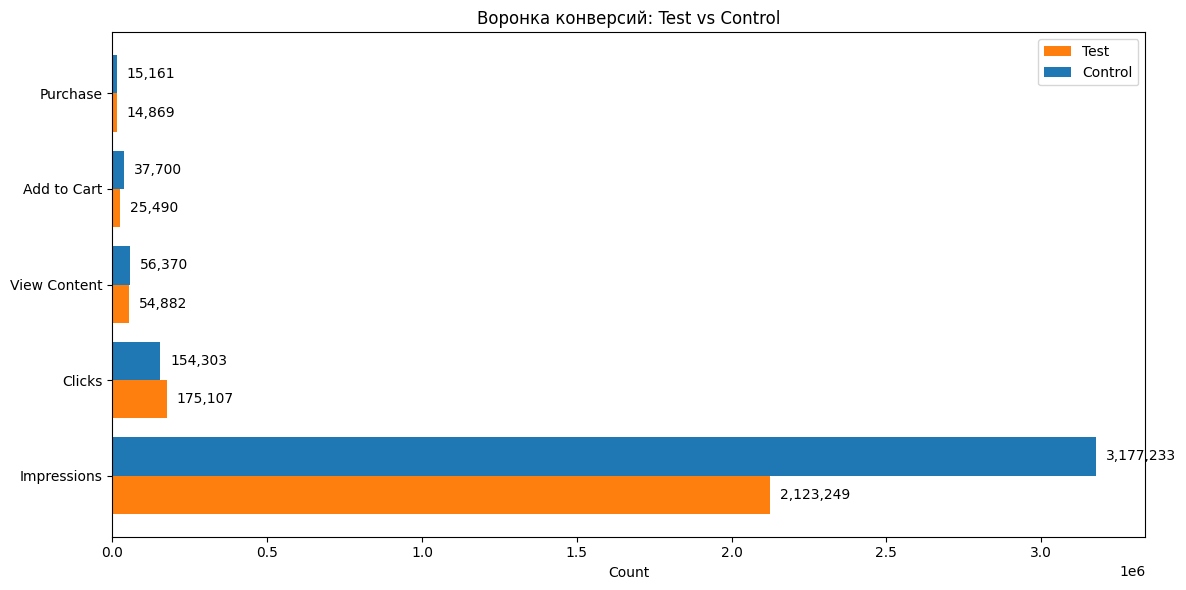

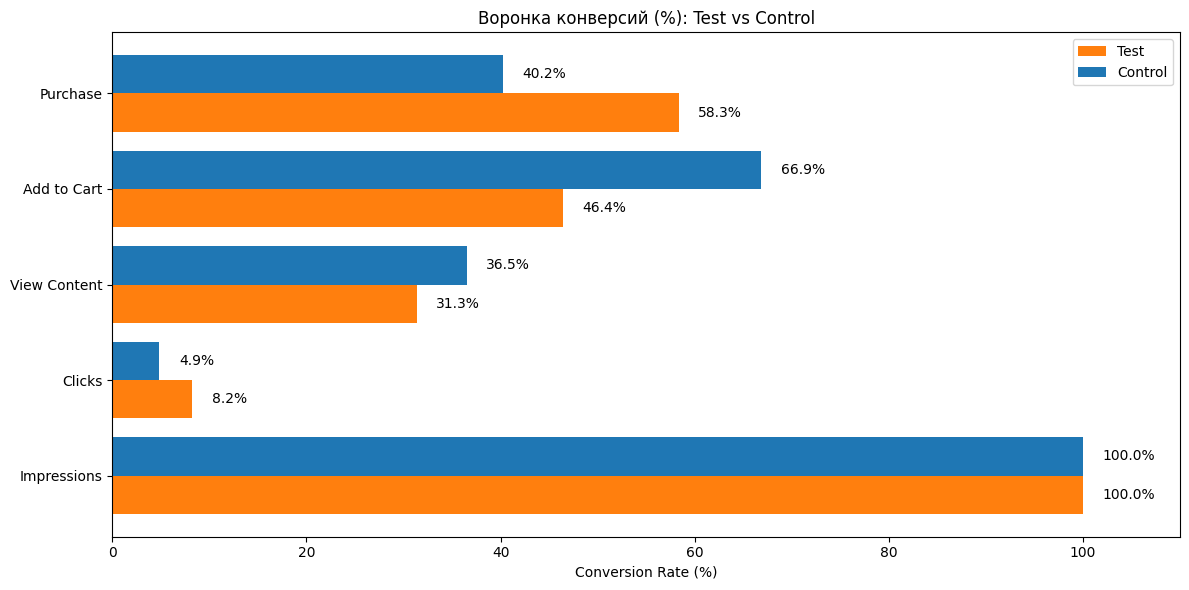

In [333]:
plot_funnel_comparison(df)

Показов рекламы в тесте гораздо меньше, при этом количество кликов из рекламы стало больше, чем в контроле.

Это говорит о том, что качество рекламного креатива улучшилось, привлечение стало работать лучше.

Из большего количества кликов в тесте просмотр контента снизился и стал меньше, чем в контрольной группе.

Снижение также наблюдается далее в добавлении в корзину.

Это значит, что несмотря на большее количество переходов, пользователи тестовой группы реже выбирают и покупают товар, т.е. тестовая кампания привлекает больше "холодных" пользователей, которые не конвертируются дальше.

Однако, стоит обратить внимание на то, что процент покупки из корзины значительно вырос, т.е. товары не остаются в корзине.

Но увеличился процент покупки из корзины, возможно на данном этапе UX лучше, чем в конторльной группе (меньше шагов, проще форма оплаты/доставки или обозначены гарантии возврата и надежность оплаты)

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.


Рекомендации:
- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).

- Обратить внимание на разницу в процессе оплаты. Если разницы нет, то различия в конверсси в оплату могут быть вызваны внешними факторами, например если тест проводился среди лояльных пользователей или в период распродаж.

### **CTR (Click-through rate)** - Доля кликов от общего числа показов

H₀: CTR не изменится

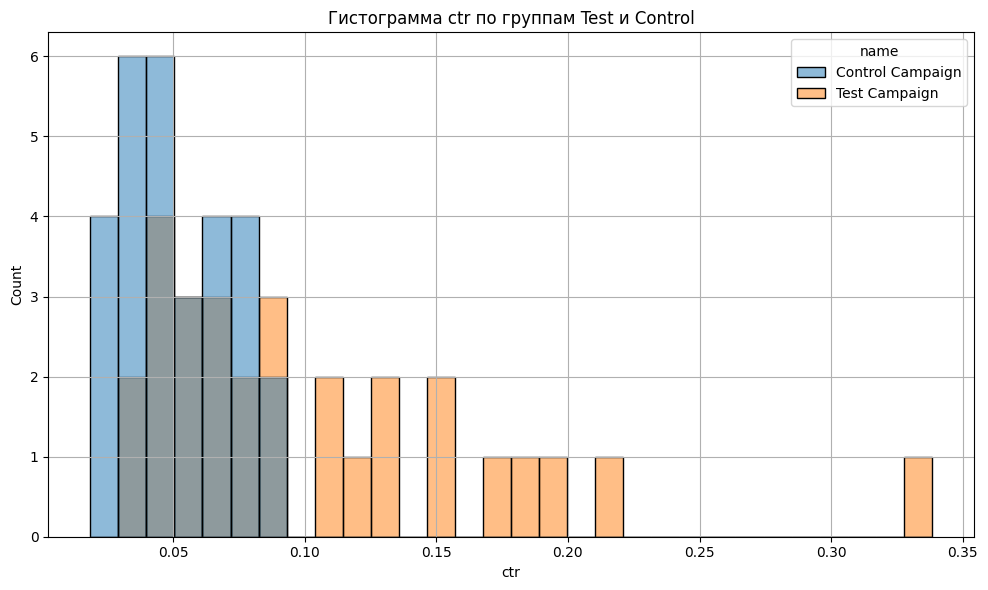

In [334]:
plot_metric_histogram(df, metric='ctr')

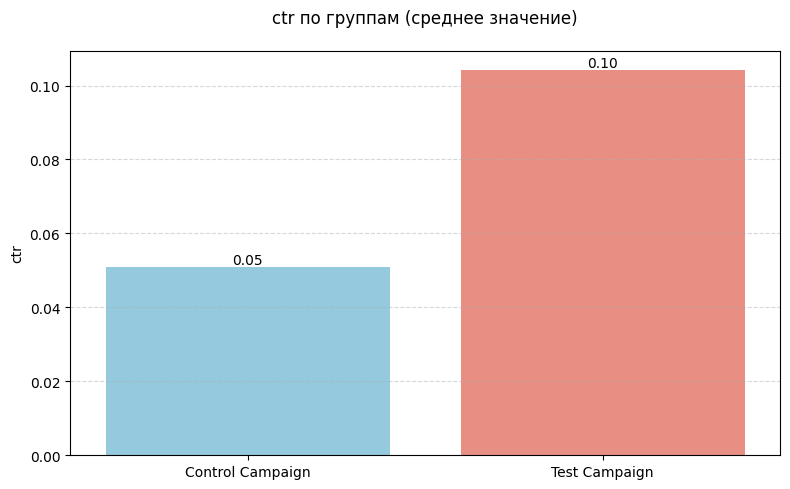

In [335]:
plot_group_metric_bar(df,metric='ctr')

In [336]:
compare_groups(df, 'ctr')

Сравнение групп по метрике 'ctr':
Контрольная группа: 0.051 (n=29)
Тестовая группа: 0.104 (n=29)
Абсолютная разница: 0.053
Относительное изменение: 104.5%


Доля кликов по рекламе выросла в 2 раза.

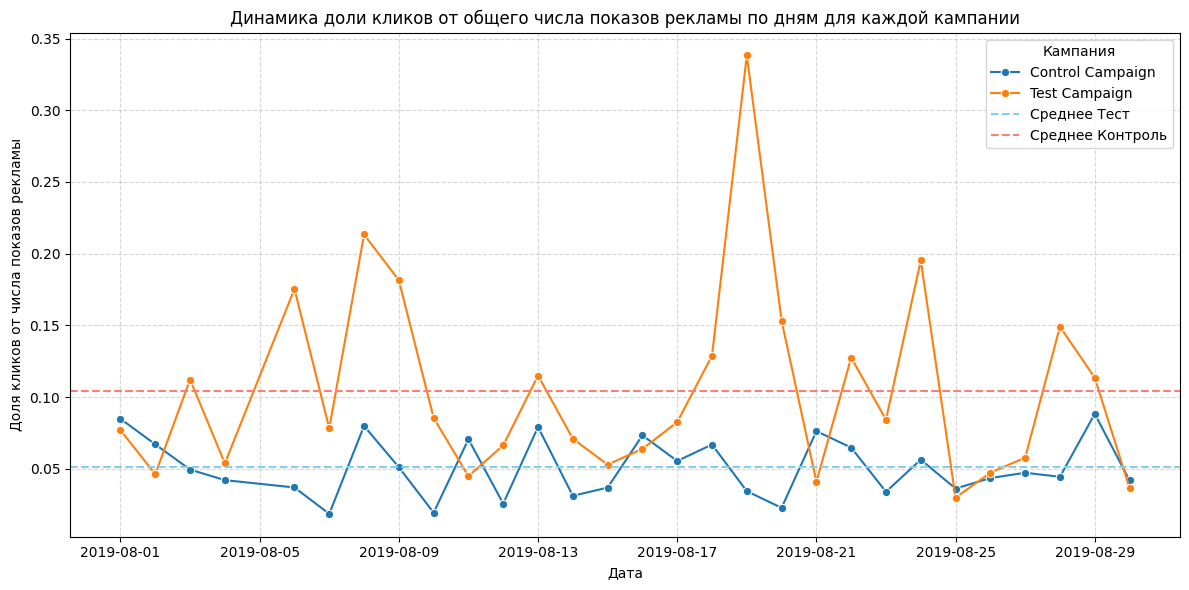

In [337]:
plot_ctr_dynamics(df)

In [338]:
result = check_normality(df, 'ctr')

Shapiro-Wilk test for 'Test Campaign': stat=0.8493, p=0.0007. 
Распределение не является нормальным (alpha=0.05).


В связи с тем, что выборка небольшая и распределение показателя CTR ненормальное, для  оценки используем Mann–Whitney U-тест.

In [339]:
results = perform_mannwhitneyu(df, 'ctr')


Результаты U-теста Манна-Уитни:

Метрика: ctr
Статистика U: 660.00
p-value: 0.0002

Вывод: Есть статистически значимые различия (p < 0.05)


Прверим гипотезу, используя бутстрап

In [340]:
results = bootstrap_metric_difference(df, 'ctr')


Бутстрап-анализ разницы средних значений:

Метрика: ctr
95% доверительный интервал: (0.029, 0.08)

Вывод: ЕСТЬ статистически значимая разница (p < 0.05)


Проверим минимально значимый эффект

In [341]:
results = calculate_mde_and_power(df, 'ctr')


Анализ мощности теста:

Метрика: ctr
Объединённое стандартное отклонение: 0.050
Cohen's d (эффект): 0.749
Минимально значимый эффект (MDE): 0.038

Вывод: Фактическая разница ПРЕВЫШАЕТ MDE — тест имеет достаточную мощность
0.053 > 0.038


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: CTR не изменится.

Анализ показал, что доля кликов увеличилась в 2 раза.

Изменения превышают значимый эффект MDE.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 660.0, p = 0.0002. **H₀ отклоняем.**

Результаты теста подтверждаются с использованием бутстрапа.

**ИТОГ**

В тестовой группе доля кликов из рекламы критически изменилась (увеличилась в 2 раза)

###**Clicks** - количество кликов из рекламы

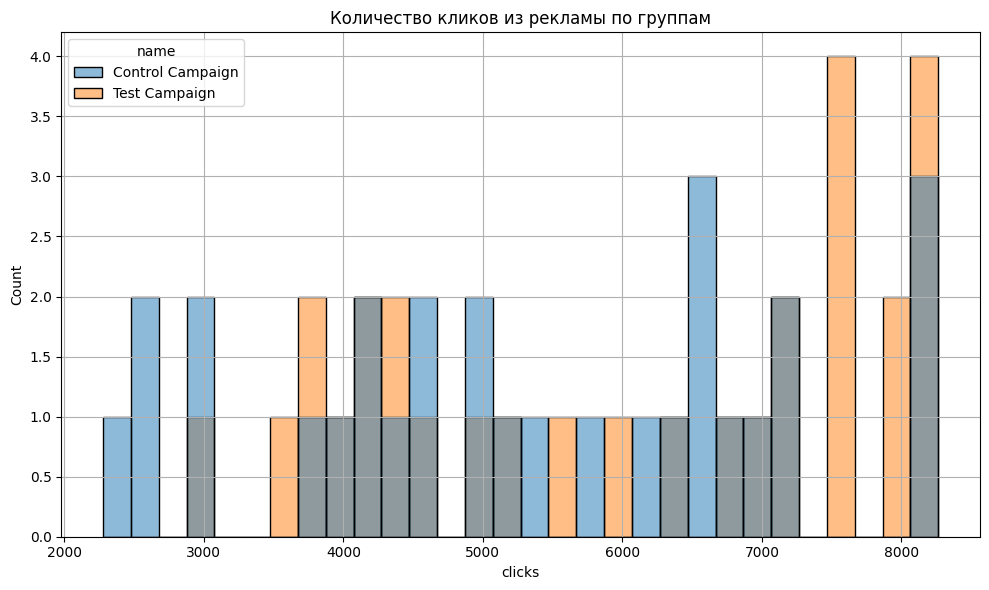

In [342]:
plot_metric_histogram(df, metric='clicks', title='Количество кликов из рекламы по группам')

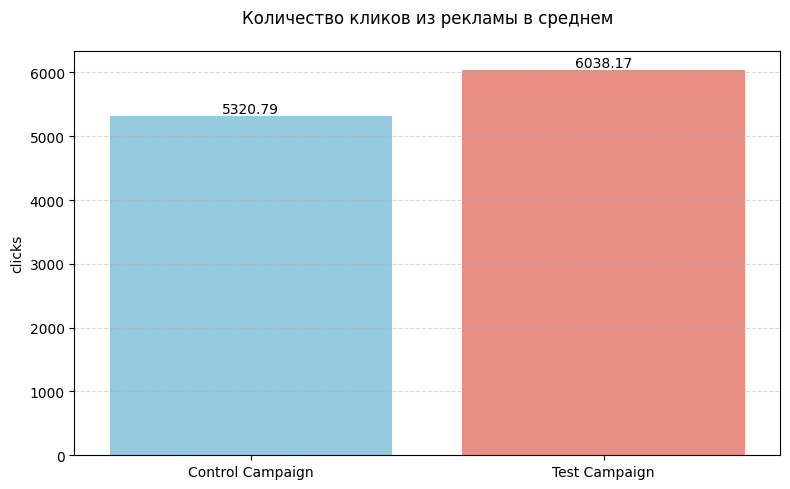

In [343]:
plot_group_metric_bar(df, metric='clicks', title='Количество кликов из рекламы в среднем')

In [344]:
compare_groups(df, 'clicks')

Сравнение групп по метрике 'clicks':
Контрольная группа: 5320.793 (n=29)
Тестовая группа: 6038.172 (n=29)
Абсолютная разница: 717.379
Относительное изменение: 13.5%


Количество кликов из рекламы увеличилось примерно на 13.5%

In [345]:
results = perform_mannwhitneyu(df, 'clicks')


Результаты U-теста Манна-Уитни:

Метрика: clicks
Статистика U: 516.00
p-value: 0.1396

Вывод: Нет значимых различий (p ≥ 0.05)


In [346]:
results = bootstrap_metric_difference(df, 'clicks')


Бутстрап-анализ разницы средних значений:

Метрика: clicks
95% доверительный интервал: (-180.418, 1609.004)

Вывод: НЕТ статистически значимой разницы (p ≥ 0.05)


In [347]:
results = calculate_mde_and_power(df, 'clicks')


Анализ мощности теста:

Метрика: clicks
Объединённое стандартное отклонение: 1747.962
Cohen's d (эффект): 0.749
Минимально значимый эффект (MDE): 1308.616

Вывод: Фактическая разница НЕ ПРЕВЫШАЕТ MDE — тест имеет недостаточную мощность
717.379 < 1308.616


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: количество кликов критически не изменится.

Анализ показал, что доля кликов увеличилась в на 15%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 516.0, p = 0.1396 > 0.05. Это говорит о том, что **нет оснований отклонять H₀.**

**ИТОГ**

В тестовой группе количество кликов из рекламы критически НЕ изменилась.

### **Impressions** - количество показов рекламы

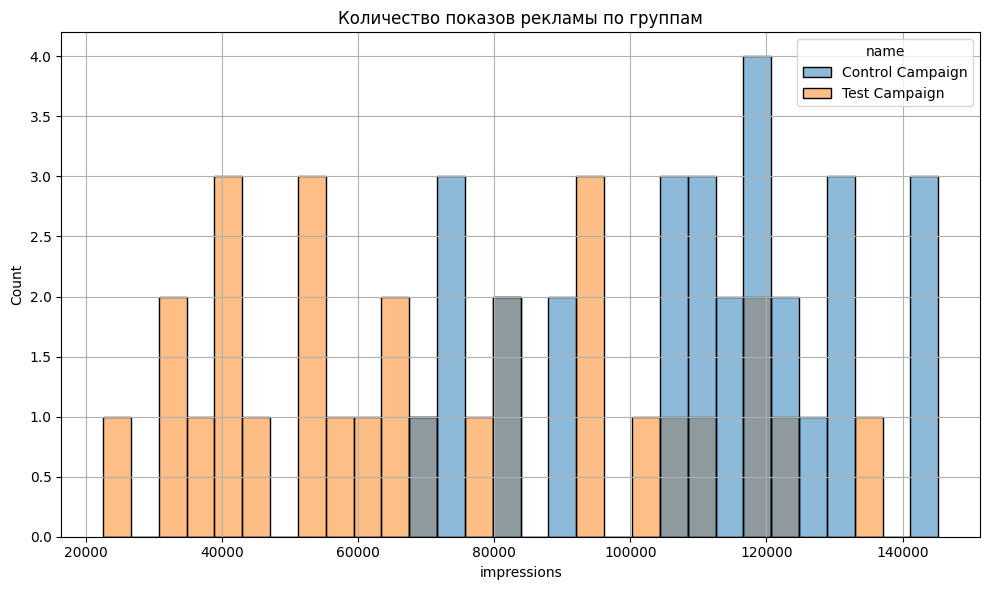

In [348]:
plot_metric_histogram(df, metric='impressions', title='Количество показов рекламы по группам')

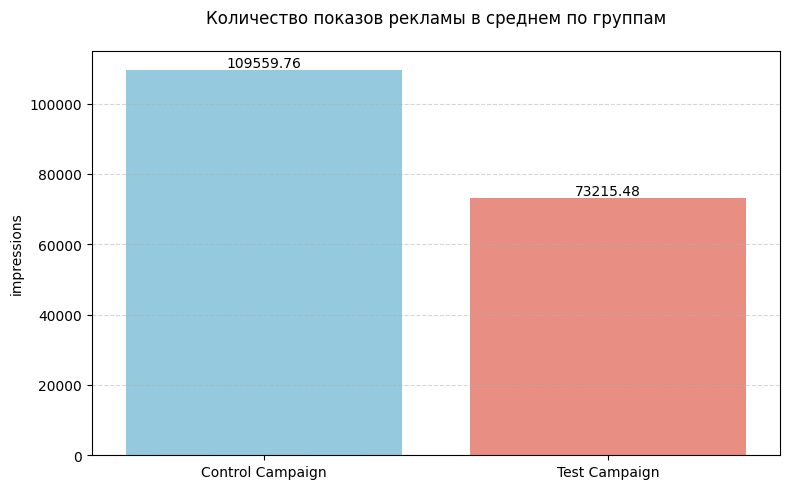

In [349]:
plot_group_metric_bar(df, metric='impressions', title='Количество показов рекламы в среднем по группам')

In [350]:
compare_groups(df, 'impressions')

Сравнение групп по метрике 'impressions':
Контрольная группа: 109559.759 (n=29)
Тестовая группа: 73215.483 (n=29)
Абсолютная разница: -36344.276
Относительное изменение: -33.2%


Количество показов рекламы сократилось примерно на 33%.

In [351]:
results = perform_mannwhitneyu(df, 'impressions')


Результаты U-теста Манна-Уитни:

Метрика: impressions
Статистика U: 158.00
p-value: 0.0000

Вывод: Есть статистически значимые различия (p < 0.05)


In [352]:
results = bootstrap_metric_difference(df, 'impressions')


Бутстрап-анализ разницы средних значений:

Метрика: impressions
95% доверительный интервал: (-49885.997, -22278.301)

Вывод: ЕСТЬ статистически значимая разница (p < 0.05)


In [353]:
results = calculate_mde_and_power(df, 'impressions')


Анализ мощности теста:

Метрика: impressions
Объединённое стандартное отклонение: 27210.125
Cohen's d (эффект): 0.749
Минимально значимый эффект (MDE): 20370.918

Вывод: Фактическая разница ПРЕВЫШАЕТ MDE — тест имеет достаточную мощность
36344.276 > 20370.918


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: количество показов рекламы не изменится.

Анализ показал, что доля показов рекламы уменьшилось на 30%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 158.0, p = 0.0000. **H₀ отклоняем.**

**ИТОГ**

В тестовой группе количество показов рекламы критически изменилась (уменьшилось примерно на 30%)

###**Add to Cart Rate** - Конверсия из просмотра в корзину

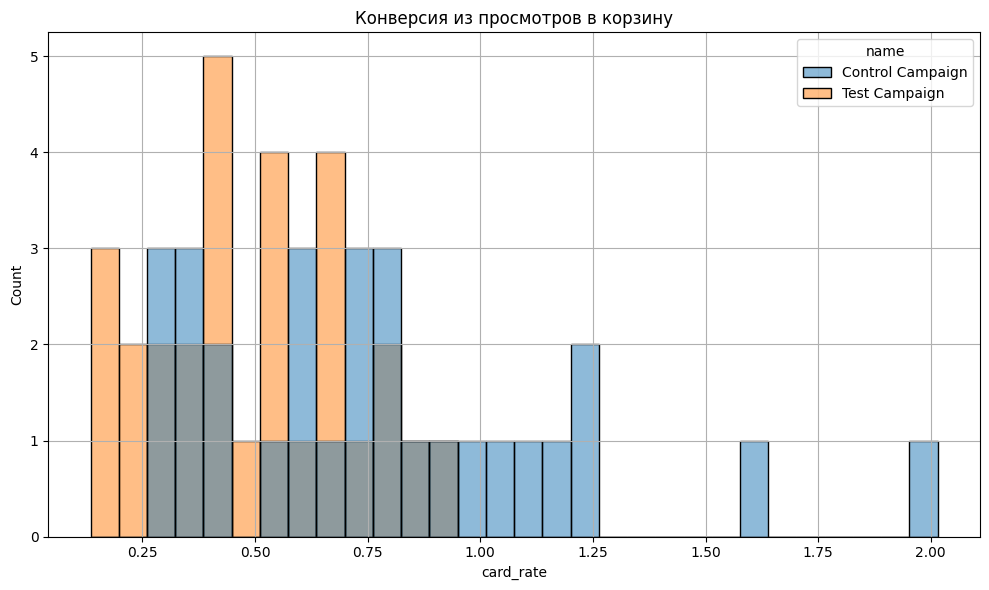

In [354]:
plot_metric_histogram(df, metric='card_rate', title='Конверсия из просмотров в корзину')

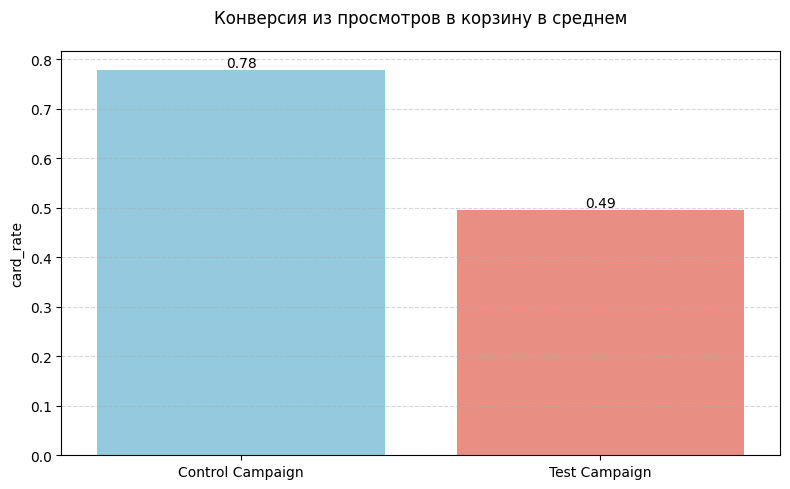

In [355]:
plot_group_metric_bar(df, metric='card_rate', title='Конверсия из просмотров в корзину в среднем')

In [356]:
compare_groups(df, 'card_rate')

Сравнение групп по метрике 'card_rate':
Контрольная группа: 0.778 (n=29)
Тестовая группа: 0.494 (n=29)
Абсолютная разница: -0.283
Относительное изменение: -36.4%


Конверсия в добавление в корзину из просмотра уменьшилась примерно на 36%

In [357]:
results = perform_mannwhitneyu(df, 'card_rate')


Результаты U-теста Манна-Уитни:

Метрика: card_rate
Статистика U: 237.00
p-value: 0.0044

Вывод: Есть статистически значимые различия (p < 0.05)


В связи с тем, что p-value близко к 0.05, дополнительно проверим гипотезу с помощью бутстрапа и определим критическое изменение.

Проверка с помощью бутстрапа:

In [358]:
results = bootstrap_metric_difference(df, 'card_rate')


Бутстрап-анализ разницы средних значений:

Метрика: card_rate
95% доверительный интервал: (-0.454, -0.121)

Вывод: ЕСТЬ статистически значимая разница (p < 0.05)


Определение минимально значимого эффекта:

In [359]:
results = calculate_mde_and_power(df, 'card_rate')


Анализ мощности теста:

Метрика: card_rate
Объединённое стандартное отклонение: 0.330
Cohen's d (эффект): 0.749
Минимально значимый эффект (MDE): 0.247

Вывод: Фактическая разница ПРЕВЫШАЕТ MDE — тест имеет достаточную мощность
0.283 > 0.247


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: конверсия из просмотра в добавление в корзину не изменится.

Анализ показал, что конверсия уменьшилось примерно на 35%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест и дполнительно проверили при помощи бутстрапа.

В резудьтате U = 237.0, p = 0.0044. **H₀ отклоняем.**

Однако, изменения на данном тесте не превышают MDE, т.е. эксперимент имеет недостаточную мощность.

**ИТОГ**

В тестовой группе конверсия в добавление в корзину изменилась (уменьшилось примерно на 35%), однако это изменение не превышает маинимально значимый эффект.

###**CPC** - Стоимость одного клика

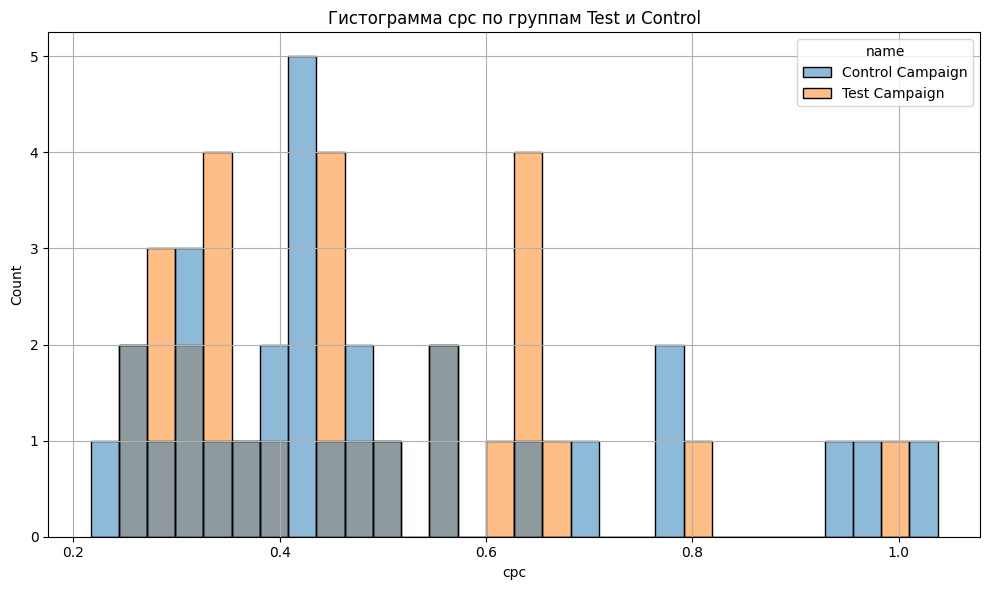

In [360]:
plot_metric_histogram(df, metric='cpc')

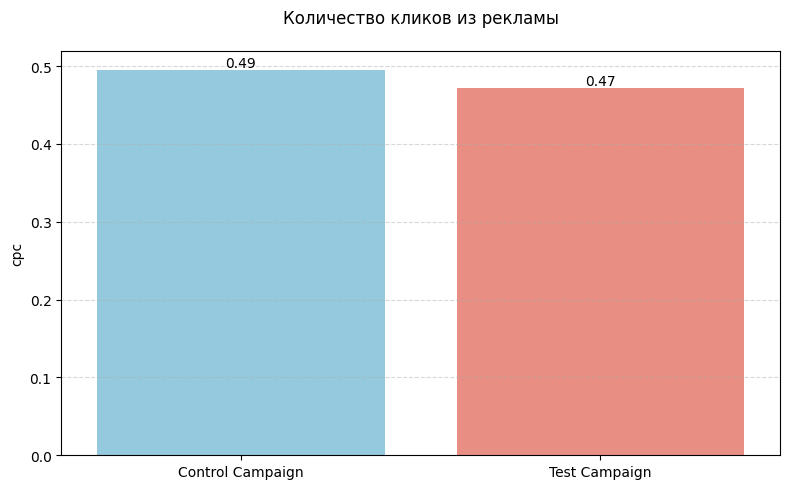

In [361]:
plot_group_metric_bar(df, metric='cpc', title='Количество кликов из рекламы')

In [362]:
compare_groups(df, 'cpc')

Сравнение групп по метрике 'cpc':
Контрольная группа: 0.495 (n=29)
Тестовая группа: 0.471 (n=29)
Абсолютная разница: -0.024
Относительное изменение: -4.8%


Стоимость одного клика немного уменьшилась

In [363]:
results = perform_mannwhitneyu(df, 'cpc')


Результаты U-теста Манна-Уитни:

Метрика: cpc
Статистика U: 409.00
p-value: 0.8642

Вывод: Нет значимых различий (p ≥ 0.05)


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: стоимость одного клика не меняется.

Анализ показал, что стоимость кликов уменьшилась.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 409.0, p = 0.8642 > 0.05, что говорит о том, что **нет оснований отклонять H₀.**

**ИТОГ**

В тестовой группе стоимость клика критически не изменилась.

###**CPATC** - стоимость одного добавления в корзину

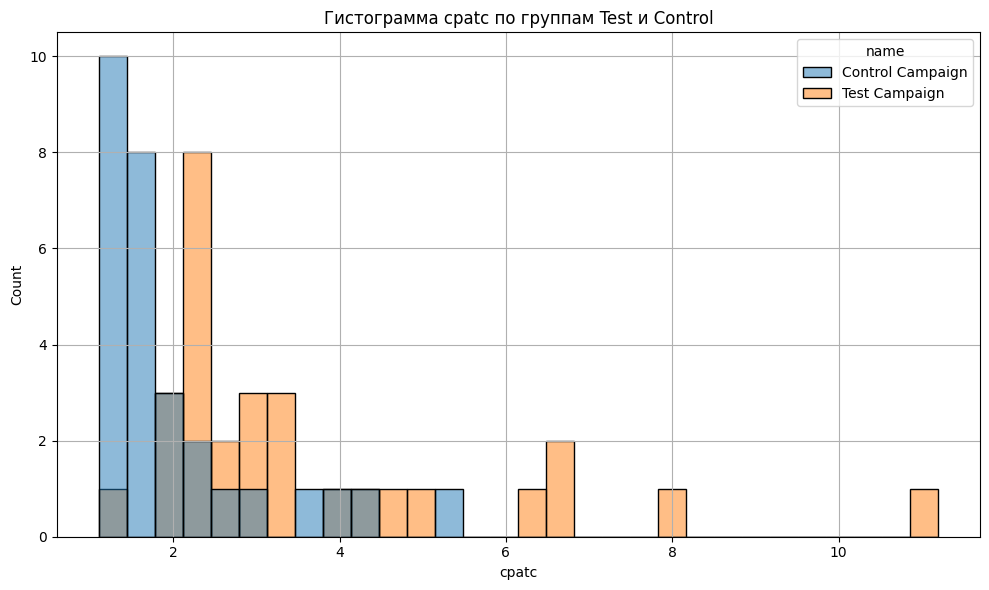

In [364]:
plot_metric_histogram(df, metric='cpatc')

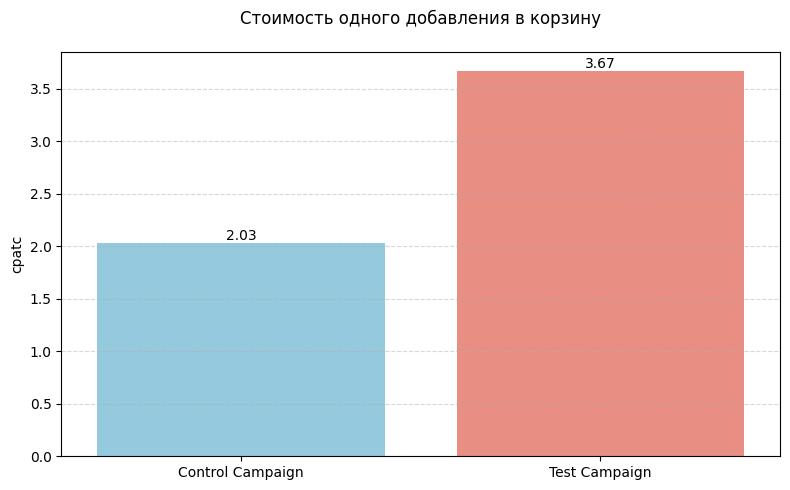

In [365]:
plot_group_metric_bar(df, metric='cpatc', title='Стоимость одного добавления в корзину')

In [366]:
compare_groups(df, 'cpatc')

Сравнение групп по метрике 'cpatc':
Контрольная группа: 2.033 (n=29)
Тестовая группа: 3.668 (n=29)
Абсолютная разница: 1.635
Относительное изменение: 80.4%


Стоимость одного добавления в корзину увеличилась примерно на 80%

In [367]:
results = perform_mannwhitneyu(df, 'cpatc')


Результаты U-теста Манна-Уитни:

Метрика: cpatc
Статистика U: 697.00
p-value: 0.0000

Вывод: Есть статистически значимые различия (p < 0.05)


В связи с тем, что p-value меньше 0.05, дополнительно проверим гипотезу с помощью бутстрапа и определим критическое изменение.

Проверка с помощью бутстрапа:

In [368]:
results = bootstrap_metric_difference(df, 'cpatc')


Бутстрап-анализ разницы средних значений:

Метрика: cpatc
95% доверительный интервал: (0.815, 2.545)

Вывод: ЕСТЬ статистически значимая разница (p < 0.05)


Определение минимально значимого эффекта:

In [369]:
results = calculate_mde_and_power(df, 'cpatc')


Анализ мощности теста:

Метрика: cpatc
Объединённое стандартное отклонение: 1.722
Cohen's d (эффект): 0.749
Минимально значимый эффект (MDE): 1.290

Вывод: Фактическая разница ПРЕВЫШАЕТ MDE — тест имеет достаточную мощность
1.635 > 1.290


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: стоимость одного добавления в корзину не меняется.

Анализ показал, что стоимость одного добавления в корзину увеличилась.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 697.0, p = 0.0000 < 0.05. **H₀ отклоняем.**

**ИТОГ**

В тестовой группе стоимость добавления в корзину изменилась (увеличилась на 90%).

# **Выводы**

Метрики, где изменения значимы:
```
Metric         Изменение   Интерпретация

Основная
ctr            +102%       Вырос Click-Through Rate от показов видимо за счет рекламы.

Прокси
impressions    -33%        Показы в тестовой кампании упали.
cpatc          +80%        Стоимоть одного добавления в корзину возросла
card_rate      -36%        В корзину добавляют реже — проблема конверсии.
```

Метрики без значимых изменений:
```
Metric         Интерпретация

clics          Хотя кликов стало больше, статистически это незначимо.
cpc            Цена за клик критически не изменилась

```

В работе учитывали размер выборки и нормальность распределений величин. Для оценки критичности изменений был выбран Mann–Whitney U-тест.

Как итог. Изменения в рекламе работают. Процент кликов из рекламы увеличился в 2 раза.

Изменение превышает значимый эффект MDE.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 660.0, p = 0.0002. **H₀ отвергаем.**

Результаты теста подтверждаются с использованием бутстрапа.

Качество рекламного креатива улучшилось.
Эффективность повысилась без увеличения затрат.

При этом стоит заметить, что конверсия в корзину на треть уменьшилась и стоимость одного добавления в корзину увеличилось на 90%. Это может говорить о том, что страница товара не соответсвует рекламе. А стоимость одной конверсии резко растёт.

**ИТОГ:**

Качество рекламного креатива улучшилось.

Эффективность рекламы повысилась без увеличения затрат.

Однако, просмотр контента и добавление в корзину снизились и стали меньше, чем в контрольной группе.

Тестовая группа лучше на верхних этапах воронки, но хуже в середине.

Но увеличился процент покупки из корзины, возможно на данном этапе UX лучше, чем в конторльной группе (меньше шагов, проще форма оплаты/доставки или обозначены гарантии возврата и надежность оплаты).

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.

Рекомендации:

- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).

- Обратить внимание на разницу в процессе оплаты. Если разницы нет, то различия в конверсси в оплату могут быть вызваны внешними факторами, например если тест проводился среди лояльных пользователей или в период распродаж, что может влиять на качество теста в целом.